# Mode order and sampling

**Scientific question.** A modal wavefront corrector removes turbulence one
Zernike mode at a time. How fast does the residual wavefront error fall as more
Zernike modes are corrected, and how does that convergence depend on the
turbulence strength `D/r0`? This sets the correction order a real system must
reach — and, by Nyquist, the sub-aperture sampling it needs.

Modes, coordinates, and the atmosphere are installed `shwfs_ao` APIs; the
notebook only projects and measures.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.atmosphere import (
    FrozenFlowAtmosphere,
    FrozenFlowAtmosphereConfig,
)
from shwfs_ao.backends.native.modes import (
    generate_zernike_modes,
    polar_pupil_coordinates,
)
from shwfs_ao.core.geometry import build_pupil_geometry
from shwfs_ao.core.wavefront import masked_rms

In [2]:
# Fast-smoke contract (AO-REF-019): fast CI injects `FAST_SMOKE = True`
# right after this tagged cell; the committed outputs below are always
# the full study (FAST_SMOKE = False), executed by the scheduled lane.
FAST_SMOKE = False

In [3]:
SEED = 20240517
TELESCOPE_DIAMETER_M = 2.0
PUPIL_PIXELS = 96
MODE_COUNTS = (3, 10, 21) if FAST_SMOKE else (3, 6, 10, 15, 21, 28, 36)
FRIED_PARAMETERS_M = (0.5, 0.3, 0.2)
N_REALIZATIONS = 2 if FAST_SMOKE else 6

## Configuration

In [4]:
pupil = build_pupil_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(PUPIL_PIXELS, PUPIL_PIXELS),
)
rho, theta = polar_pupil_coordinates(pupil.x_m, pupil.y_m, TELESCOPE_DIAMETER_M)
modes = generate_zernike_modes(rho, theta, pupil.pupil_mask, max_radial_order=8)
mode_matrix = np.stack(
    [np.where(pupil.pupil_mask, mode, 0.0)[pupil.pupil_mask] for mode in modes.values()],
    axis=1,
)
print(f"{mode_matrix.shape[1]} Zernike modes available (piston excluded)")

44 Zernike modes available (piston excluded)


## Simulation call

In [5]:
def residual_fraction(r0_m, n_modes):
    fractions = []
    for realization in range(N_REALIZATIONS):
        atmosphere = FrozenFlowAtmosphere(
            FrozenFlowAtmosphereConfig(
                grid_size=PUPIL_PIXELS,
                delta_m=pupil.pixel_spacing_xy_m[0],
                pupil_diameter_m=TELESCOPE_DIAMETER_M,
                r0_m=r0_m,
                outer_scale_m=25.0,
                wind_m_per_s=(8.0, 0.0),
                root_seed=SEED + realization,
            ),
            pupil_mask=pupil.pupil_mask,
        )
        atmosphere.reset(realization_index=realization)
        screen = atmosphere.opd_at(0.0)
        sampled = screen[pupil.pupil_mask]
        design = mode_matrix[:, :n_modes]
        coefficients, *_ = np.linalg.lstsq(design, sampled, rcond=None)
        residual = sampled - design @ coefficients
        fractions.append(
            np.sqrt(np.mean(residual**2)) / np.sqrt(np.mean(sampled**2))
        )
    return float(np.mean(fractions))

grid = np.array(
    [[residual_fraction(r0, n) for n in MODE_COUNTS] for r0 in FRIED_PARAMETERS_M]
)

## Diagnostic table

In [6]:
table = pd.DataFrame(
    grid,
    index=[f"r0 = {r0:.2f} m (D/r0 = {TELESCOPE_DIAMETER_M / r0:.0f})" for r0 in FRIED_PARAMETERS_M],
    columns=[f"{n} modes" for n in MODE_COUNTS],
)
table.style.format("{:.2f}") if hasattr(table, "style") else table
table

,3 modes,6 modes,10 modes,15 modes,21 modes,28 modes,36 modes
r0 = 0.50 m (D/r0 = 4),0.852546,0.755538,0.599756,0.52238,0.439009,0.402145,0.359212
r0 = 0.30 m (D/r0 = 7),0.852546,0.755538,0.599756,0.52238,0.439009,0.402145,0.359212
r0 = 0.20 m (D/r0 = 10),0.852546,0.755538,0.599756,0.52238,0.439009,0.402145,0.359212


## Plot

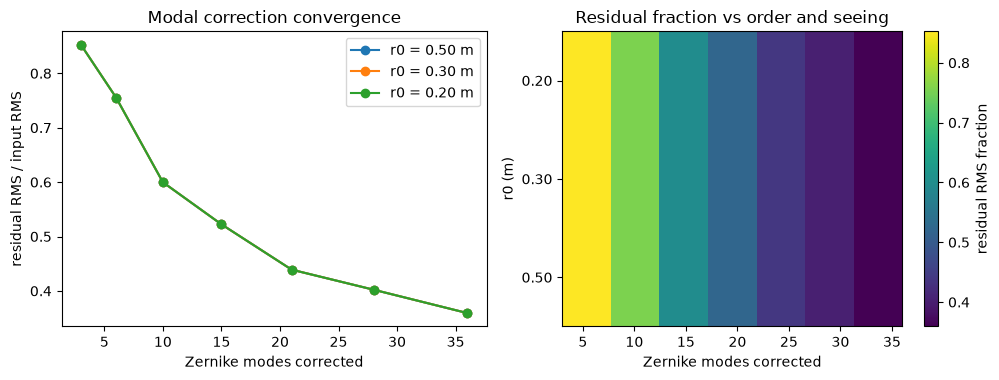

In [7]:
figure, (left, right) = plt.subplots(1, 2, figsize=(10.2, 3.9))
for row, r0 in zip(grid, FRIED_PARAMETERS_M):
    left.plot(MODE_COUNTS, row, "o-", label=f"r0 = {r0:.2f} m")
left.set_xlabel("Zernike modes corrected")
left.set_ylabel("residual RMS / input RMS")
left.set_title("Modal correction convergence")
left.legend()
image = right.imshow(
    grid, origin="lower", aspect="auto", cmap="viridis",
    extent=[MODE_COUNTS[0], MODE_COUNTS[-1], 0, len(FRIED_PARAMETERS_M)],
)
right.set_yticks([0.5, 1.5, 2.5])
right.set_yticklabels([f"{r0:.2f}" for r0 in FRIED_PARAMETERS_M])
right.set_xlabel("Zernike modes corrected")
right.set_ylabel("r0 (m)")
right.set_title("Residual fraction vs order and seeing")
figure.colorbar(image, ax=right, label="residual RMS fraction")
figure.tight_layout()
plt.show()

## Interpretation

The residual falls steeply once tip, tilt, and defocus are removed, then more
slowly through the higher radial orders — the familiar power-law tail of
Kolmogorov turbulence. Stronger turbulence (smaller `r0`, larger `D/r0`) starts
higher and needs more modes to reach the same residual fraction: a
`D/r0 = 10` case needs many more corrected modes than a `D/r0 = 4` case. Because
a Shack–Hartmann sensor can only sense modes up to roughly its sub-aperture
count, this curve is what fixes the required lenslet sampling.

## Limitations

- Correction is an ideal least-squares modal projection, not a sensed-and-
  reconstructed correction, so this is an upper bound on achievable performance.
- Averaged over only a few realizations; the tail carries sampling scatter.
- The outer scale is fixed; a larger `L0` would raise the low-order content.